# Assessment Task 1
## Section 1(a): SVM Classifier with LBP
### 1. Extract files and Install all required dependencies and 

In [1]:
!unzip student_25349642.zip

Archive:  student_25349642.zip
replace student_25349642/+/+_100242.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: ^C


In [2]:
!pip install opencv-python-headless

  Using cached opencv_python_headless-4.13.0.92-cp37-abi3-manylinux_2_28_x86_64.whl.metadata (19 kB)
  Using cached numpy-2.4.3-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
Using cached opencv_python_headless-4.13.0.92-cp37-abi3-manylinux_2_28_x86_64.whl (60.4 MB)
Using cached numpy-2.4.3-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (16.6 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [opencv-python-headless]v-python-headless]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
autogluon-multimodal 1.5.0 requires nvidia-ml-py3<8.0,>=7.352.0, which is not installed.
autogluon-timeseries 1.5.0 requires chronos-forecasting<2.4,>=2.2.2, which is not installed.
autogluo

In [3]:
!pip install split-folders

  Using cached split_folders-0.6.1-py3-none-any.whl.metadata (11 kB)
Using cached split_folders-0.6.1-py3-none-any.whl (13 kB)


In [4]:
import splitfolders

splitfolders.ratio("student_25349642", output="output", seed=1337, ratio=(.8, .1, .1),
                   group_prefix=None, group=None, formats=(".jpg", ".jpeg", ".png"), move=False, shuffle=True)

Copying files: 5000 files [00:04, 1132.21 files/s]


### 2. Dataset Preparation

**Finish writing in the section headings AFTER completing all the code**

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import feature # This pacakge is used for LBP feature extraction
from sklearn import svm # This pacakge is used for svm classification
from sklearn import metrics
%matplotlib inline
import cv2
import seaborn as sns # This pacakge is used for better visualization of data (e.g confusion matrix)
import os
from sklearn.model_selection import train_test_split
from skimage.feature import local_binary_pattern
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [1]:
labelName = ['+', 'beta', 'cos', 'leq', 'M', 'N', 'R', 'rightarrow', 'S', 'z']

def load_dataset(path):

    data = []
    labels = []

    for label in labelName:
        class_path = os.path.join(path, label)

        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)

            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            img = cv2.resize(img, (28, 28))

            data.append(img.flatten())
            labels.append(labelName.index(label))
            
    return np.array(data), np.array(labels)

In [7]:
X_train, y_train = load_dataset('./output/train')
X_test, y_test = load_dataset('./output/test')
X_val, y_val = load_dataset('./output/val')

In [8]:
print(np.shape(X_train))
print(np.shape(X_test))
print(np.shape(X_val))

(4000, 784)
(500, 784)
(500, 784)


In [9]:
X_train=X_train.reshape(-1,28,28)
X_test=X_test.reshape(-1,28,28)
X_val=X_val.reshape(-1,28,28)

# print the size of the result reshaped train and test data splits

print("Train dataset after reshaping:{}".format(np.shape(X_train)))
print("Test dataset after reshaping :{}".format(np.shape(X_test)))
print("Val dataset after reshaping :{}".format(np.shape(X_val)))

Train dataset after reshaping:(4000, 28, 28)
Test dataset after reshaping :(500, 28, 28)
Val dataset after reshaping :(500, 28, 28)


+
cos
rightarrow
rightarrow


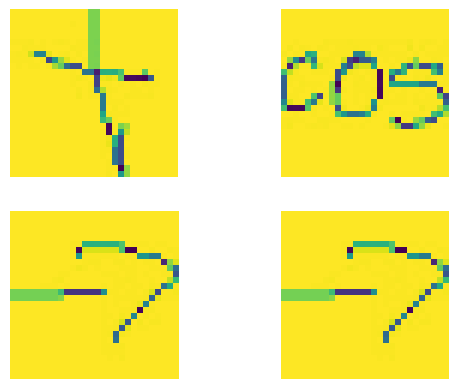

In [10]:
img_index = 10
fig = plt.figure()
ax1 = fig.add_subplot(2,2,1)
ax1.axis('off')
ax1.imshow(X_train[img_index])
print(labelName[y_train[img_index]])

ax2 = fig.add_subplot(2,2,2)
ax2.axis('off')
img_index = 1000
ax2.imshow(X_train[img_index])
print(labelName[y_train[img_index]])

ax2 = fig.add_subplot(2,2,3)
ax2.axis('off')
img_index = 3000
ax2.imshow(X_train[img_index])
print(labelName[y_train[img_index]])

ax2 = fig.add_subplot(2,2,4)
ax2.axis('off')
img_index = 3000
ax2.imshow(X_train[img_index])
print(labelName[y_train[img_index]])

In [11]:
class LocalBinaryPatterns:
	def __init__(self, numPoints, radius):
		# store the number of points and radius
		self.numPoints = numPoints
		self.radius = radius

	def LBPfeatures(self, image, eps=1e-7):
		# compute the Local Binary Pattern representation
		# of the image, and then use the LBP representation
		# to build the histogram of patterns
		lbp = feature.local_binary_pattern(image, self.numPoints,
			self.radius, method="uniform")
    # Form the histogram
		(hist, _) = np.histogram(lbp.ravel(),
			bins=np.arange(0, self.numPoints + 3),
			range=(0, self.numPoints + 2))

		# normalize the histogram
		hist = hist.astype("float")
		hist /= (hist.sum() + eps)

		# return the histogram of Local Binary Patterns
		return hist

In [12]:
# Create an object of LocalBinaryPatterns class and initial the parameters.
desc = LocalBinaryPatterns(24, 8)
data_train = []
labels_train = []

## WRITE YOUR CODE HERE (~ 3 lines)
# loop over the training images
for img_index in range(len(X_train)):
	# load the train image, and extract LBP features
	image = (X_train[img_index])
	hist = desc.LBPfeatures(image)
## END YOUR CODE HERE

	# extract the label from the image path, then update the
	# label and data lists
	labels_train.append(y_train[img_index])
	data_train.append(hist)

In [13]:
# train a SVM clasifier on the training data
# Initialize the SVM model
# Use rbf Kernel, c = 100 and randon_state=42

## WRITE YOUR CODE HERE (~ 2 lines)
model = svm.SVC(kernel='rbf', C = 100, random_state = 42, gamma='scale')
# Start training the SVM classifier
model.fit(data_train, labels_train)
## END YOUR CODE HERE

data_val = []
labels_val = []

for img_index in range(len(X_val)):
    image = (X_val[img_index])
    hist = desc.LBPfeatures(image)

    labels_val.append(y_val[img_index])
    data_val.append(hist)

val_accuracy = model.score(data_val, labels_val)
print("Validation Accuracy:", val_accuracy)

print(np.shape(data_train))
print(np.shape(labels_train))

Validation Accuracy: 0.608
(4000, 26)
(4000,)


In [14]:
# Check the training accuray
print("Train set Accuracy: {:.2f}".format(model.score(data_train,labels_train)))

# Expected training set Accuracy 0.60

Train set Accuracy: 0.60


In [15]:
predictions=[]
predict_label=[]
# Exract LBP features for each test sample and classify it with the trained SVM classifier

## WRITE YOUR CODE HERE (~ 2 lines)
for im_index in range(len(X_test)):
  imag = X_test[im_index]

  # Extract LBP feature
  histo = desc.LBPfeatures(imag)
  # Perform classification, Hint: use model.predict()
  prediction = model.predict(histo.reshape(1, -1))[0]
## END YOUR CODE HERE

  # Store the classfication result
  predictions.append(prediction)
  predict_label.append(y_test[im_index])

In [16]:
accuracy = metrics.accuracy_score(y_test, predictions)
print("Accuracy on test dataset:",accuracy)

Accuracy on test dataset: 0.614


[[41  0  0  3  1  0  0  5  0  0]
 [ 0 39  1  2  3  0  3  0  1  1]
 [ 0  3 44  1  1  0  0  0  1  0]
 [ 2  1  0 33  4  3  0  5  1  1]
 [ 0  7  3  6 18  6  0  4  1  5]
 [ 1  4  1  5  3 26  0  3  4  3]
 [ 1  5  1  3  1  1 29  6  0  3]
 [ 6  1  0  6  3  0  1 31  1  1]
 [ 1  3  0  2  4  2  1  3 29  5]
 [ 3  3  4  3  6  6  0  0  8 17]]


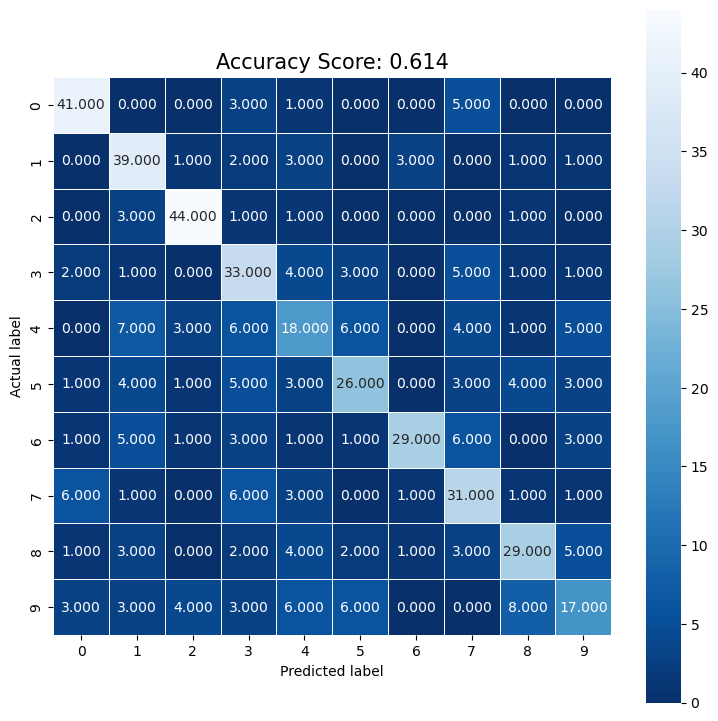

In [17]:
# plot the confusion matrix
cm  = metrics.confusion_matrix(y_test, predictions)
print(cm)

# Plot confusion matrix using seaborn library
plt.figure(figsize=(9,9))
sns.heatmap(cm, annot=True, fmt=".3f", linewidths=.5, square = True, cmap = 'Blues_r');
plt.ylabel('Actual label');
plt.xlabel('Predicted label');
all_sample_title = 'Accuracy Score: {0}'.format(accuracy)
plt.title(all_sample_title, size = 15);

In [18]:
# Display some classification result on test samples
images = []
pred_label = []
true_label = []

# randomly select a few testing fashion items
for i in np.random.choice(np.arange(0, len(y_test)), size=(16,)):
  # classify the clothing
  histog = desc.LBPfeatures(X_test[i])
  prediction = model.predict(histog.reshape(1, -1))[0]
  label = labelName[prediction]
  orig_label = labelName[y_test[i]]
  image = X_test[i]
  image = cv2.merge([image] * 3)
  image = cv2.resize(image, (96, 96), interpolation=cv2.INTER_LINEAR)

  # cv2.putText(image, f"Predicted Label: {label}", (5, 20), cv2.FONT_HERSHEY_SIMPLEX, 0.50, (0, 255, 0), 2)
  # cv2.putText(image, f"True Label: {orig_label}", (5, 20), cv2.FONT_HERSHEY_SIMPLEX, 0.50, (255, 0, 0), 2)
    
  images.append(image)
  pred_label.append(label)
  true_label.append(orig_label)

In [19]:
np.shape(images[1])

(96, 96, 3)

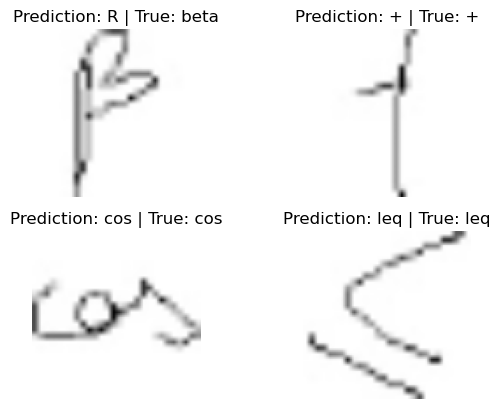

In [20]:
## Display the classification results
#Plot the image and the predicted labels
fig = plt.figure()
ax1 = fig.add_subplot(2,2,1)
ax1.imshow(images[0])
ax1.set_title(f"Prediction: {pred_label[0]} | True: {true_label[0]}")
ax1.axis("off")
ax2 = fig.add_subplot(2,2,2)
ax2.imshow(images[1])
ax2.set_title(f"Prediction: {pred_label[1]} | True: {true_label[1]}")
ax2.axis("off")
ax3 = fig.add_subplot(2,2,3)
ax3.imshow(images[2])
ax3.set_title(f"Prediction: {pred_label[2]} | True: {true_label[2]}")
ax3.axis("off")
ax4 = fig.add_subplot(2,2,4)
ax4.imshow(images[3])
ax4.set_title(f"Prediction: {pred_label[3]} | True: {true_label[3]}")
ax4.axis("off")
plt.show()

In [27]:
print("Test Accuracy: ", accuracy_score(y_test, predictions))

print(classification_report(y_test, predictions, target_names=labelName))

Test Accuracy:  0.614
              precision    recall  f1-score   support

           +       0.75      0.82      0.78        50
        beta       0.59      0.78      0.67        50
         cos       0.81      0.88      0.85        50
         leq       0.52      0.66      0.58        50
           M       0.41      0.36      0.38        50
           N       0.59      0.52      0.55        50
           R       0.85      0.58      0.69        50
  rightarrow       0.54      0.62      0.58        50
           S       0.63      0.58      0.60        50
           z       0.47      0.34      0.40        50

    accuracy                           0.61       500
   macro avg       0.62      0.61      0.61       500
weighted avg       0.62      0.61      0.61       500



## SVM + HOG

In [31]:
# initialize the data matrix and labels
print("Extracting features from training dataset...")
data_train = []
labels_train = []

# loop over the training images
for img_index in range(len(X_train)):
  # load the image, and extract HOG features it
  ## WRITE YOUR CODE HERE ## (~ 4 lines)
  image = (X_train[img_index])

  # Hint: use orientation =9, pixel_per_cell=(10,10), cells_per_block=2,2,
  # transform_sqrt=True and block_norm="L2-Hys"
  #
  H = feature.hog(image, orientations=9, pixels_per_cell=(10,10), cells_per_block=(2,2), transform_sqrt=True, block_norm='L2-Hys') # Complete the code

  # update the data and labels
  data_train.append(H) # Complete the code
  labels_train.append(y_train[img_index]) # Complete the code
## END YOUR CODE HERE ##
print(np.shape(data_train))
print(np.shape(labels_train))

Extracting features from training dataset...
(4000, 36)
(4000,)


In [35]:
## WRITE YOUR CODE HERE ## (~ 2 lines)
model = svm.SVC(kernel='rbf', C = 100, random_state = 42)
model.fit(data_train, labels_train)
## END YOUR CODE HERE ##

,C,100
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [36]:
print("Train set Accuracy: {:.2f}".format(model.score(data_train,labels_train)))

Train set Accuracy: 1.00


In [37]:
# initialize the data matrix and labels
print("Extracting features from test dataset...")
predict_test = []
labels_test = []
data_test=[]
# loop over the training images
for img_ind in range(len(X_test)):
  # load the image, and extract HOG features
  ## WRITE YOUR CODE HERE ## (~ 6 lines), refer to task-1 code if required
  img=X_test[img_ind]
  H = feature.hog(img, orientations=9, pixels_per_cell=(10,10), cells_per_block=(2,2), transform_sqrt=True, block_norm='L2-Hys')# Hint: use same settings as used in training phase

  pred = model.predict(H.reshape(1,-1))[0]
  # update the data and labels
  predict_test.append(pred)
  data_test.append(H)

  labels_test.append(y_test[img_ind])
  ## END YOUR CODE HERE ##

print(np.shape(predict_test))
print(np.shape(labels_test))

Extracting features from test dataset...
(500,)
(500,)


In [38]:
# Test set Accuracy
## WRITE YOUR CODE HERE ## (~ 2 lines)
accuracy = metrics.accuracy_score(y_test, predict_test)
print("Accuracy on test dataset:", accuracy)
## END YOUR CODE HERE ##
# Expected test Accuracy 0.75

Accuracy on test dataset: 0.876


[[49  0  0  0  0  1  0  0  0  0]
 [ 0 46  0  0  0  1  2  0  0  1]
 [ 0  0 45  0  4  0  0  0  0  1]
 [ 0  0  0 48  0  0  0  0  2  0]
 [ 0  0  2  0 42  6  0  0  0  0]
 [ 1  1  0  0  5 37  6  0  0  0]
 [ 1  2  1  1  4  8 32  0  1  0]
 [ 1  0  0  0  0  1  0 48  0  0]
 [ 0  0  0  0  1  1  0  0 48  0]
 [ 2  1  1  0  2  1  0  0  0 43]]


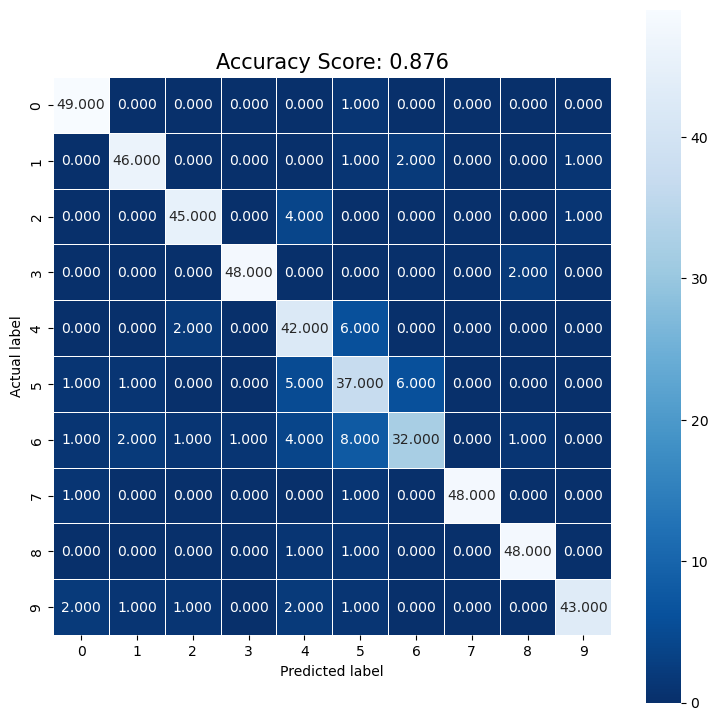

In [39]:
# plot the confusion matrix
## WRITE YOUR CODE HERE ## (~ 2 lines)
cm  = metrics.confusion_matrix(y_test, predict_test)
print(cm)
## END YOUR CODE HERE ##

# Plot confusion matrix using seaborn library
plt.figure(figsize=(9,9))
sns.heatmap(cm, annot=True, fmt=".3f", linewidths=.5, square = True, cmap = 'Blues_r');
plt.ylabel('Actual label');
plt.xlabel('Predicted label');
all_sample_title = 'Accuracy Score: {0}'.format(accuracy)
plt.title(all_sample_title, size = 15);

In [42]:
images = []
orig_labels=[]
# randomly select a few testing fashion items
for i in np.random.choice(np.arange(0, len(y_test)), size=(16,)):
  # classify the clothing
  test_img = (X_test[i])
  H1 = feature.hog(test_img, orientations=9, pixels_per_cell=(10, 10),
                  cells_per_block=(2, 2), transform_sqrt=True, block_norm="L2-Hys")
  pred = model.predict(H1.reshape(1, -1))[0]
  #prediction = model.predict(test_img.reshape(1, -1))
  label = labelName[pred]
  orig_labels.append(labelName[y_test[i]])
  color = (0, 255, 0)
  test_img = cv2.merge([test_img] * 3)
  test_img = cv2.resize(test_img, (96, 96), interpolation=cv2.INTER_LINEAR)
  cv2.putText(test_img, label, (5, 20), cv2.FONT_HERSHEY_SIMPLEX, 0.50, color, 2)
  images.append(test_img)

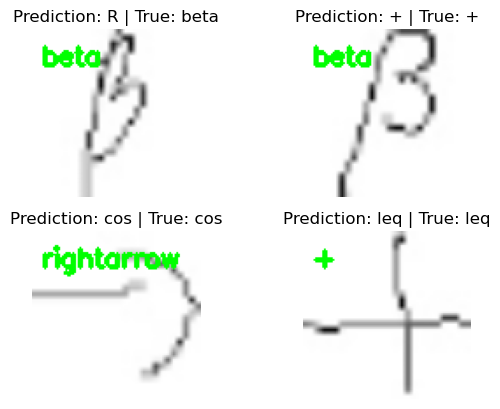

In [43]:
## Display the classification results
#Plot the image and the predicted labels
fig = plt.figure()
ax5 = fig.add_subplot(2,2,1)
ax5.imshow(images[0])
ax5.set_title(f"Prediction: {pred_label[0]} | True: {true_label[0]}")
ax5.axis("off")
ax6 = fig.add_subplot(2,2,2)
ax6.imshow(images[1])
ax6.set_title(f"Prediction: {pred_label[1]} | True: {true_label[1]}")
ax6.axis("off")
ax7 = fig.add_subplot(2,2,3)
ax7.imshow(images[2])
ax7.set_title(f"Prediction: {pred_label[2]} | True: {true_label[2]}")
ax7.axis("off")
ax8 = fig.add_subplot(2,2,4)
ax8.imshow(images[3])
ax8.set_title(f"Prediction: {pred_label[3]} | True: {true_label[3]}")
ax8.axis("off")
plt.show()